<a href="https://colab.research.google.com/github/Santibareiro27/Inteligencia-Computacional/blob/alex/RA1_LAB3/EXPERIENCIA_1%20/RA1_Lab_N%C2%B03_EXP1_G8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Experiencia 1 – Sistema de diagnostico fitosanitario en cultivos de te

Clasificacion automatica de imagenes de hojas de te en 8 categorias: siete enfermedades frecuentes y hoja sana. Requerimiento de despliegue: tablet de campo sin conexion, inferencia < 2 s/imagen.

Dataset:

In [10]:
!pip install -q tensorflow matplotlib seaborn scikit-learn numpy pandas pillow

In [11]:
import os, gc, json, random, time, warnings, zipfile, shutil
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from PIL import Image, UnidentifiedImageError

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import MobileNetV3Small, EfficientNetB0, ResNet50
from tensorflow.keras.applications.mobilenet_v3 import preprocess_input as mob_v3_preproc
from tensorflow.keras.applications.efficientnet  import preprocess_input as eff_preproc
from tensorflow.keras.applications.resnet50      import preprocess_input as res_preproc
from tensorflow.keras.callbacks import (EarlyStopping, ModelCheckpoint,
                                        ReduceLROnPlateau)
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED); np.random.seed(SEED)
tf.random.set_seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)

IMG_SIZE    = 224
BATCH_SIZE  = 32
NUM_CLASSES = 8
AUTOTUNE    = tf.data.AUTOTUNE
EXTENSIONS  = {".jpg", ".jpeg", ".png", ".bmp", ".tiff", ".webp"}

FIGURES_DIR = "/content/figures"
MODELS_DIR  = "/content/models"
os.makedirs(FIGURES_DIR, exist_ok=True)
os.makedirs(MODELS_DIR,  exist_ok=True)

results = {}  # acumula metricas para la tabla comparativa

print(f"TensorFlow : {tf.__version__}")
print(f"GPU        : {len(tf.config.list_physical_devices('GPU')) > 0}")


# ── Capa de preprocesamiento serializable (reemplaza layers.Lambda) ───────────
# Lambda con funciones Python no es serializable en Keras 3.x.
# Esta capa registrada globalmente se guarda/carga sin safe_mode ni problemas.
@keras.utils.register_keras_serializable(package='TeaApp')
class PreprocessLayer(keras.layers.Layer):
    """
    Aplica el preprocess_input del backbone elegido.
    Serializable en Keras 3.x sin restricciones de safe_mode.
    """
    _FN_MAP: dict = {}   # se llena debajo, despues de los imports

    def __init__(self, backbone_name: str, **kwargs):
        super().__init__(**kwargs)
        self.backbone_name = backbone_name

    def call(self, inputs):
        return PreprocessLayer._FN_MAP[self.backbone_name](inputs)

    def compute_output_shape(self, input_shape):
        return input_shape          # preprocessing no cambia el shape

    def get_config(self):
        cfg = super().get_config()
        cfg["backbone_name"] = self.backbone_name
        return cfg

PreprocessLayer._FN_MAP = {
    "mobilenet_v3": mob_v3_preproc,
    "efficientnet":  eff_preproc,
    "resnet50":      res_preproc,
}


TensorFlow : 2.20.0
GPU        : False


## Persistencia en Google Drive

Montar Drive permite guardar modelos y el historial de entrenamiento entre sesiones, evitando reentrenar desde cero si el runtime de Colab se reinicia. `USE_DRIVE = False` desactiva este comportamiento (solo almacenamiento local).

In [12]:
USE_DRIVE        = True   # Cambiar a False para omitir Drive
DRIVE_MODELS_DIR = "/content/drive/MyDrive/RA1_Exp1_models"

if USE_DRIVE:
    try:
        from google.colab import drive
        drive.mount("/content/drive", force_remount=False)
        os.makedirs(DRIVE_MODELS_DIR, exist_ok=True)
        print(f"Drive montado. Modelos en: {DRIVE_MODELS_DIR}")
    except Exception as e:
        print(f"Drive no disponible ({e}). Usando solo almacenamiento local.")
        USE_DRIVE = False
else:
    print("Persistencia en Drive desactivada.")


Mounted at /content/drive
Drive montado. Modelos en: /content/drive/MyDrive/RA1_Exp1_models


## Sistema de checkpoints y reanudacion

`train_or_load()` entrena el modelo si no existe guardado, o lo carga directamente si ya se ejecuto en una sesion anterior. El historial se serializa en JSON para poder graficar sin reentrenar. Si `USE_DRIVE=True`, al terminar el entrenamiento copia el modelo a Drive.

In [13]:
class DriveBackupCallback(tf.keras.callbacks.Callback):
    """Copia el mejor modelo a Drive al final de cada epoca."""
    def __init__(self, local_path, drive_path):
        super().__init__()
        self.local_path = local_path
        self.drive_path = drive_path

    def on_epoch_end(self, epoch, logs=None):
        if USE_DRIVE and os.path.exists(self.local_path):
            shutil.copy(self.local_path, self.drive_path)


class EpochCheckpointCallback(tf.keras.callbacks.Callback):
    """
    Guarda un checkpoint cada `save_freq` epocas y serializa el historial
    parcial en JSON. Permite reanudar si el runtime de Colab se reinicia.
    Conserva solo el ultimo checkpoint para no desperdiciar disco.
    """
    def __init__(self, ckpt_dir, save_freq=5, drive_dir=None, model_name=""):
        super().__init__()
        self.ckpt_dir   = ckpt_dir
        self.save_freq  = save_freq
        self.drive_dir  = drive_dir
        self.model_name = model_name
        self.hist       = {}

    def on_epoch_end(self, epoch, logs=None):
        for k, v in (logs or {}).items():
            self.hist.setdefault(k, []).append(float(v))

        if (epoch + 1) % self.save_freq == 0:
            os.makedirs(self.ckpt_dir, exist_ok=True)
            path = os.path.join(self.ckpt_dir, f"epoch_{epoch+1:04d}.keras")
            self.model.save(path)
            with open(os.path.join(self.ckpt_dir, "history_partial.json"), "w") as f:
                json.dump(self.hist, f)
            for old in sorted(Path(self.ckpt_dir).glob("epoch_*.keras"))[:-1]:
                old.unlink()
            if USE_DRIVE and self.drive_dir:
                dst = os.path.join(self.drive_dir, f"{self.model_name}_ckpt_latest.keras")
                shutil.copy(path, dst)


class HistoryLike:
    """Wrapper para history cargado desde JSON, compatible con plot_history."""
    def __init__(self, data):
        self.history = data


def load_keras_model(path, compile=True):
    """
    Carga un modelo Keras.
    PreprocessLayer esta registrada globalmente con register_keras_serializable,
    por lo que no requiere safe_mode=False ni custom_objects explícitos.
    """
    return keras.models.load_model(path, compile=compile)


def train_or_load(model, model_name, ds_train, ds_val, ds_test,
                  epochs, lr, patience=8, reduce_lr=False,
                  monitor_metric="val_accuracy"):
    """
    Tres estados:
      1. Modelo completo + historial existen  ->  SKIP  (carga directo).
      2. Checkpoints de epoca existen         ->  RESUME (retoma desde el ultimo).
      3. Sin nada guardado                    ->  TRAIN desde cero.
    """
    keras_path   = f"{MODELS_DIR}/{model_name}.keras"
    history_path = f"{MODELS_DIR}/{model_name}_history.json"
    ckpt_dir     = f"{MODELS_DIR}/{model_name}_ckpts"
    drive_keras  = f"{DRIVE_MODELS_DIR}/{model_name}.keras"        if USE_DRIVE else None
    drive_hist   = f"{DRIVE_MODELS_DIR}/{model_name}_history.json" if USE_DRIVE else None

    # Estado 0: copiar desde Drive si no existe localmente
    if not os.path.exists(keras_path) and USE_DRIVE and drive_keras and os.path.exists(drive_keras):
        print(f"[DRIVE] Copiando {model_name} desde Drive...")
        shutil.copy(drive_keras, keras_path)
        if drive_hist and os.path.exists(drive_hist):
            shutil.copy(drive_hist, history_path)

    # Estado 1: SKIP — compile=True para poder llamar .evaluate() directamente
    if os.path.exists(keras_path) and os.path.exists(history_path):
        print(f"[SKIP] {model_name} ya entrenado. Cargando desde disco...")
        loaded = load_keras_model(keras_path, compile=True)
        with open(history_path) as f:
            hist_data = json.load(f)
        return loaded, HistoryLike(hist_data), 0.0

    # Estado 2: RESUME desde checkpoint de epoca
    initial_epoch = 0
    partial_hist  = {}
    ckpt_files    = sorted(Path(ckpt_dir).glob("epoch_*.keras")) if os.path.isdir(ckpt_dir) else []

    if ckpt_files:
        latest_ckpt   = str(ckpt_files[-1])
        initial_epoch = int(ckpt_files[-1].stem.replace("epoch_", ""))
        print(f"[RESUME] {model_name}: reanudando desde epoca {initial_epoch}...")
        model = load_keras_model(latest_ckpt, compile=False)
        hist_partial_path = os.path.join(ckpt_dir, "history_partial.json")
        if os.path.exists(hist_partial_path):
            with open(hist_partial_path) as f:
                partial_hist = json.load(f)

    # Estado 3: TRAIN
    os.makedirs(ckpt_dir, exist_ok=True)
    mode = "max" if any(m in monitor_metric for m in ("accuracy", "auc")) else "min"
    cbs  = [
        EarlyStopping(monitor="val_loss", patience=patience,
                      restore_best_weights=True, verbose=1),
        ModelCheckpoint(keras_path, monitor=monitor_metric,
                        mode=mode, save_best_only=True, verbose=0),
        EpochCheckpointCallback(ckpt_dir, save_freq=5,
                                drive_dir=DRIVE_MODELS_DIR if USE_DRIVE else None,
                                model_name=model_name),
    ]
    if reduce_lr:
        cbs.append(ReduceLROnPlateau(monitor="val_loss", factor=0.5,
                                     patience=4, min_lr=1e-7, verbose=1))
    if USE_DRIVE and drive_keras:
        cbs.append(DriveBackupCallback(keras_path, drive_keras))

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss="categorical_crossentropy",
        metrics=["accuracy"],
    )
    t0      = time.time()
    history = model.fit(
        ds_train, validation_data=ds_val,
        epochs=epochs,
        initial_epoch=initial_epoch,
        callbacks=cbs, verbose=1
    )
    elapsed = time.time() - t0

    combined = dict(partial_hist)
    for k, v in history.history.items():
        combined[k] = combined.get(k, []) + list(v)

    with open(history_path, "w") as f:
        json.dump(combined, f)
    if USE_DRIVE and drive_hist:
        shutil.copy(history_path, drive_hist)

    for ckpt in Path(ckpt_dir).glob("epoch_*.keras"):
        ckpt.unlink()
    hist_p = os.path.join(ckpt_dir, "history_partial.json")
    if os.path.exists(hist_p):
        os.remove(hist_p)

    print(f"[OK] {model_name} — {elapsed:.0f}s ({elapsed/60:.1f} min).")
    return model, HistoryLike(combined), elapsed


In [14]:
LIMPIAR_MODELOS = 0
if LIMPIAR_MODELOS:
    for d in [MODELS_DIR, DRIVE_MODELS_DIR if USE_DRIVE else None]:
        if d and os.path.exists(d):
            shutil.rmtree(d)
            os.makedirs(d, exist_ok=True)
            print(f"Limpiado: {d}")
    print("Listo. El sistema reentrenara todo desde cero en las celdas siguientes.")
else:
    print("Limpieza omitida (LIMPIAR_MODELOS=False).")

Limpieza omitida (LIMPIAR_MODELOS=False).


## Carga del dataset

In [15]:
DATASET_DIR = "/content/tea_dataset"

if not os.path.exists(DATASET_DIR):
    try:
        !gdown --id 1ac6EkoBBxCEnJNcJO438DGHhGQKaTELx -O /content/tea_sickness_dataset.zip -q
        with zipfile.ZipFile("/content/tea_sickness_dataset.zip", "r") as z:
            z.extractall(DATASET_DIR)
        os.remove("/content/tea_sickness_dataset.zip")
        print("Dataset extraido.")
    except Exception as e:
        print(f"Descarga fallo: {e}. Montar Drive y descomentar bloque alternativo:")
        # from google.colab import drive; drive.mount("/content/drive")
        # with zipfile.ZipFile("/content/drive/MyDrive/tea_sickness_dataset.zip","r") as z:
        #     z.extractall(DATASET_DIR)
else:
    print("Dataset disponible.")

subdirs      = [d for d in Path(DATASET_DIR).iterdir() if d.is_dir()]
DATASET_ROOT = str(subdirs[0]) if len(subdirs) == 1 else DATASET_DIR
class_dirs   = sorted([d for d in Path(DATASET_ROOT).iterdir() if d.is_dir()])
CLASS_NAMES  = [d.name for d in class_dirs]
print(f"Clases ({len(CLASS_NAMES)}): {CLASS_NAMES}")


/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Dataset extraido.
Clases (8): ['Anthracnose', 'algal leaf', 'bird eye spot', 'brown blight', 'gray light', 'healthy', 'red leaf spot', 'white spot']


---
## Bloque 1 – Analisis Exploratorio del Dataset (EDA)

### 1.1 Distribucion de clases

Total: 885 imagenes | 8 clases
  red leaf spot            :  143  ( 16.2%)
  white spot               :  142  ( 16.0%)
  algal leaf               :  113  ( 12.8%)
  brown blight             :  113  ( 12.8%)
  Anthracnose              :  100  ( 11.3%)
  bird eye spot            :  100  ( 11.3%)
  gray light               :  100  ( 11.3%)
  healthy                  :   74  (  8.4%)


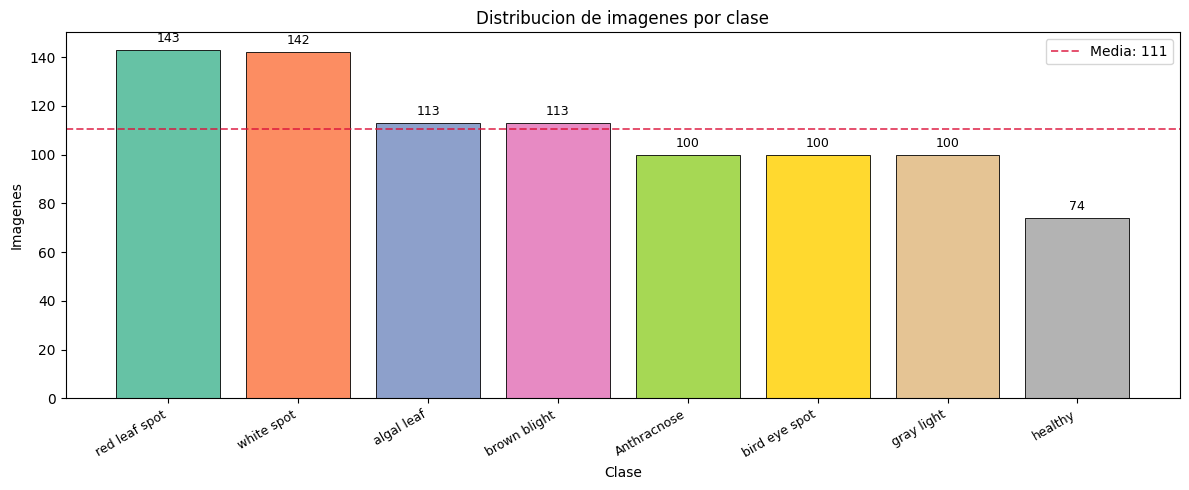

In [16]:
all_image_paths, all_labels = [], []
class_counts = {}

for cdir in class_dirs:
    imgs = [f for f in cdir.iterdir() if f.suffix.lower() in EXTENSIONS]
    class_counts[cdir.name] = len(imgs)
    all_image_paths.extend([str(f) for f in imgs])
    all_labels.extend([cdir.name] * len(imgs))

total = sum(class_counts.values())
sorted_cls = sorted(class_counts, key=lambda x: -class_counts[x])
sorted_cnt = [class_counts[c] for c in sorted_cls]
media      = total / len(class_counts)

print(f"Total: {total} imagenes | {len(class_counts)} clases")
for cls, cnt in zip(sorted_cls, sorted_cnt):
    print(f"  {cls:25s}: {cnt:4d}  ({cnt/total*100:5.1f}%)")

fig, ax = plt.subplots(figsize=(12, 5))
colors = plt.cm.Set2(np.linspace(0, 1, len(sorted_cls)))
bars = ax.bar(sorted_cls, sorted_cnt, color=colors, edgecolor="black", linewidth=0.6)
ax.axhline(media, color="crimson", ls="--", lw=1.4, alpha=0.75,
           label=f"Media: {media:.0f}")
for bar, cnt in zip(bars, sorted_cnt):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
            str(cnt), ha="center", va="bottom", fontsize=9)
ax.set_xlabel("Clase"); ax.set_ylabel("Imagenes")
ax.set_title("Distribucion de imagenes por clase"); ax.legend()
plt.xticks(rotation=30, ha="right", fontsize=9)
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/01_distribucion_clases.png", dpi=150, bbox_inches="tight")
plt.show()


### 1.2 Dimensiones de imagen

Ancho  | min: 768  max: 4160  media: 1844
Alto   | min: 1024  max: 4160  media: 2039
Canales: {'RGB': 634}


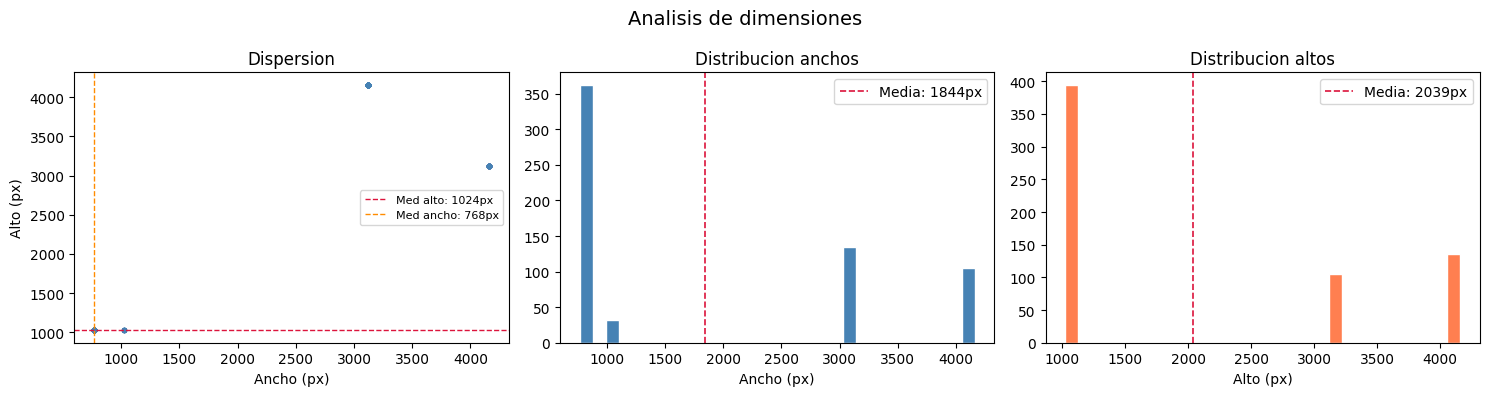


--- Estimacion de parametros por backbone (previo al entrenamiento) ---
  MobileNetV3Small    : ~2.5M params | FLOPs aprox: 0.0G
  EfficientNetB0      : ~5.3M params | FLOPs aprox: 0.0G
  ResNet50            : ~25.6M params | FLOPs aprox: 0.0G
Modelos con <6M params son candidatos para inferencia movil rapida.


In [17]:
random.seed(SEED)
widths, heights, n_channels = [], [], []
for cdir in class_dirs:
    imgs = [f for f in cdir.iterdir() if f.suffix.lower() in EXTENSIONS]
    for p in random.sample(imgs, min(80, len(imgs))):
        try:
            img = Image.open(p)
            w, h = img.size
            widths.append(w); heights.append(h)
            n_channels.append(len(img.getbands()))
        except Exception:
            continue

widths = np.array(widths); heights = np.array(heights)
ch_u, ch_c = np.unique(n_channels, return_counts=True)
ch_lbl = {1: "Grises", 3: "RGB", 4: "RGBA"}

print(f"Ancho  | min: {widths.min()}  max: {widths.max()}  media: {widths.mean():.0f}")
print(f"Alto   | min: {heights.min()}  max: {heights.max()}  media: {heights.mean():.0f}")
print("Canales:", {ch_lbl.get(ch, ch): int(c) for ch, c in zip(ch_u, ch_c)})

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].scatter(widths, heights, alpha=0.35, s=8, c="steelblue")
axes[0].axhline(np.median(heights), color="crimson",    ls="--", lw=1,
                label=f"Med alto: {np.median(heights):.0f}px")
axes[0].axvline(np.median(widths),  color="darkorange", ls="--", lw=1,
                label=f"Med ancho: {np.median(widths):.0f}px")
axes[0].set_xlabel("Ancho (px)"); axes[0].set_ylabel("Alto (px)")
axes[0].set_title("Dispersion"); axes[0].legend(fontsize=8)
axes[1].hist(widths, bins=30, color="steelblue", edgecolor="white", lw=0.4)
axes[1].axvline(widths.mean(), color="crimson", ls="--", lw=1.2,
                label=f"Media: {widths.mean():.0f}px")
axes[1].set_xlabel("Ancho (px)"); axes[1].set_title("Distribucion anchos"); axes[1].legend()
axes[2].hist(heights, bins=30, color="coral", edgecolor="white", lw=0.4)
axes[2].axvline(heights.mean(), color="crimson", ls="--", lw=1.2,
                label=f"Media: {heights.mean():.0f}px")
axes[2].set_xlabel("Alto (px)"); axes[2].set_title("Distribucion altos"); axes[2].legend()
plt.suptitle("Analisis de dimensiones", fontsize=14)
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/02_dimensiones_imagenes.png", dpi=150, bbox_inches="tight")
plt.show()

# Estimacion de capacidad computacional ANTES de entrenar
# (proxy para seleccion de backbone por hardware)
print("""
--- Estimacion de parametros por backbone (previo al entrenamiento) ---""")
for name, params_m in [("MobileNetV3Small", 2.5), ("EfficientNetB0", 5.3), ("ResNet50", 25.6)]:
    flops_est = params_m * IMG_SIZE * IMG_SIZE * 2 / 1e9  # estimacion muy aproximada
    print(f"  {name:20s}: ~{params_m:.1f}M params | FLOPs aprox: {flops_est:.1f}G")
print("Modelos con <6M params son candidatos para inferencia movil rapida.")

### 1.3 Muestras por clase

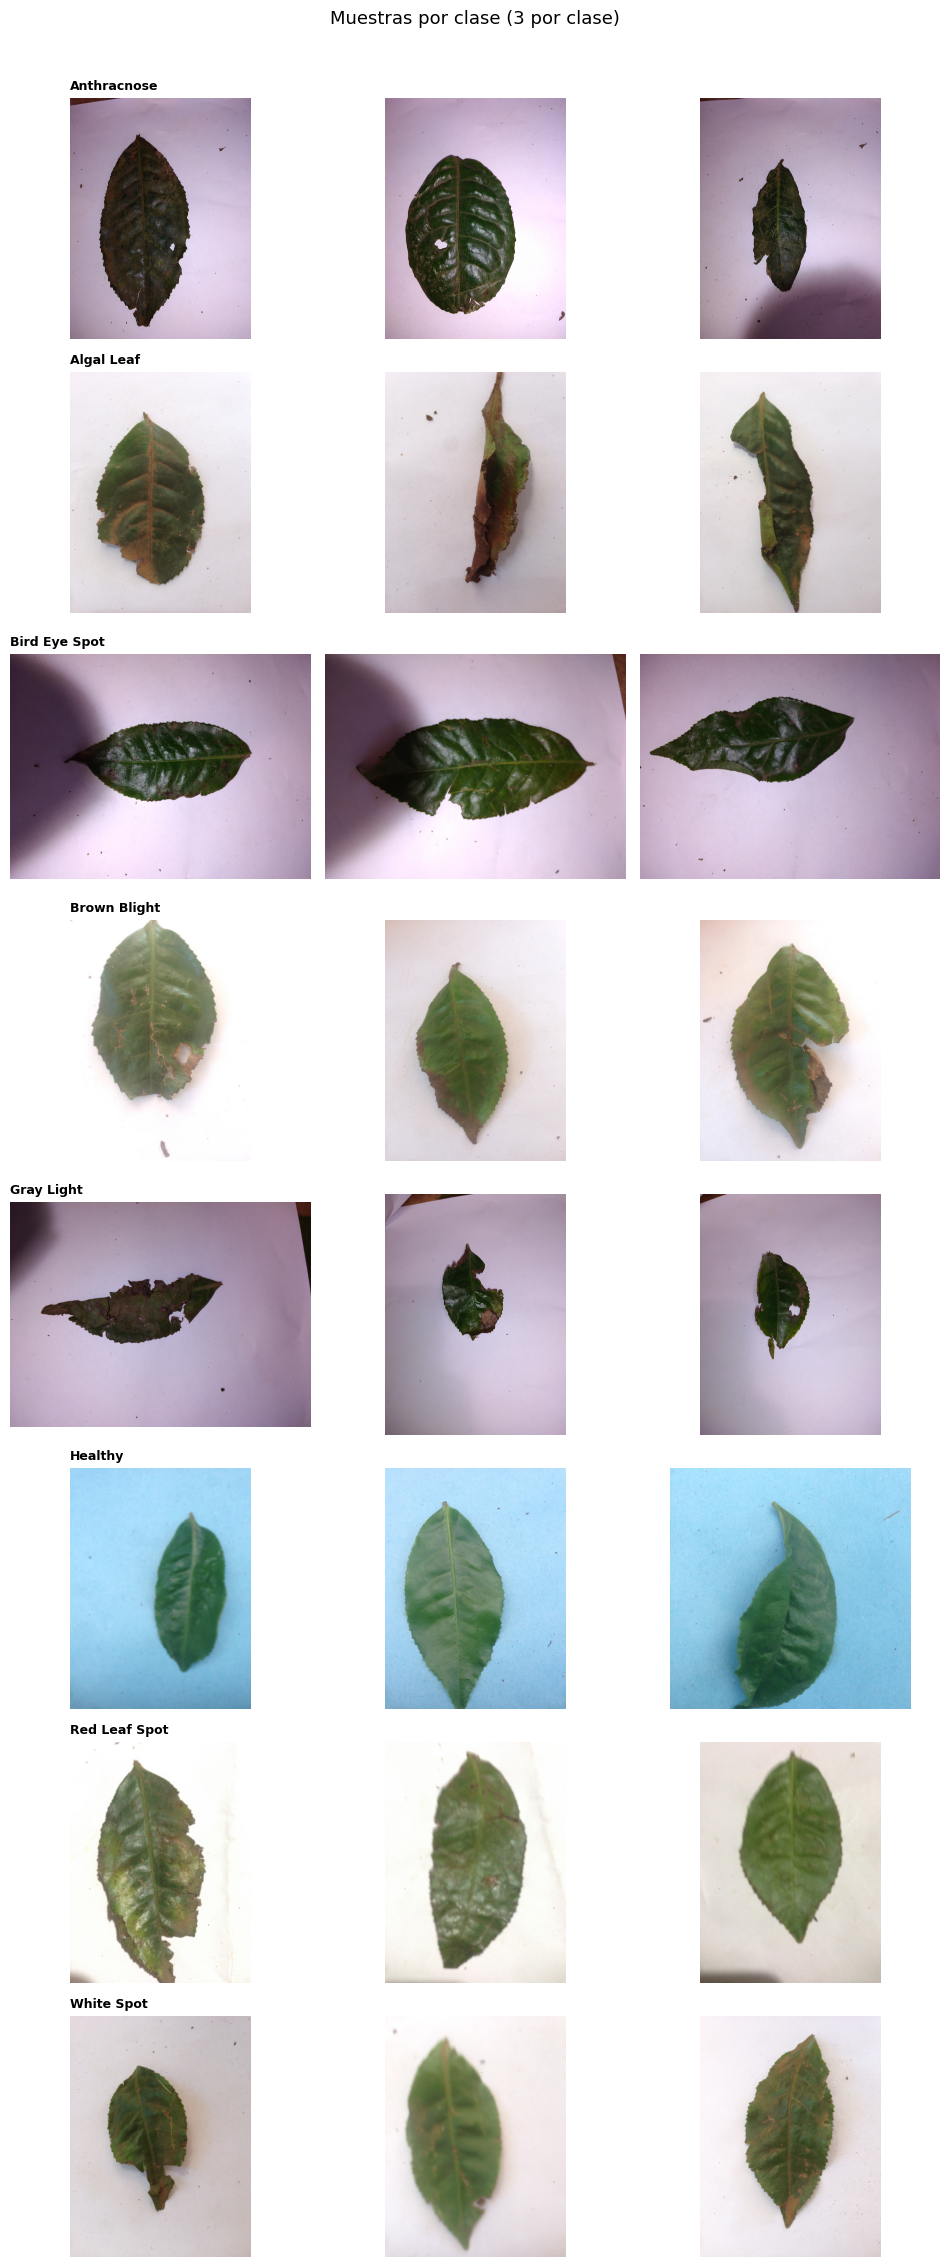

In [18]:
random.seed(SEED)
n_per = 3
fig, axes = plt.subplots(len(class_dirs), n_per,
                         figsize=(n_per * 3.2, len(class_dirs) * 2.8))
for i, cdir in enumerate(class_dirs):
    imgs   = [f for f in cdir.iterdir() if f.suffix.lower() in EXTENSIONS]
    sample = random.sample(imgs, min(n_per, len(imgs)))
    for j in range(n_per):
        ax = axes[i, j]
        if j < len(sample):
            ax.imshow(Image.open(sample[j]).convert("RGB"))
        ax.axis("off")
        if j == 0:
            ax.set_title(cdir.name.replace("_", " ").title(),
                         fontsize=9, loc="left", fontweight="bold")
plt.suptitle("Muestras por clase (3 por clase)", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/03_muestras_por_clase.png", dpi=150, bbox_inches="tight")
plt.show()


### 1.4 Calidad del dataset

In [19]:
corrupt, zero_size = [], []
for path in all_image_paths:
    p = Path(path)
    if p.stat().st_size == 0:
        zero_size.append(path); continue
    try:
        img = Image.open(path); img.verify()
    except Exception:
        corrupt.append(path)

problematic = set(corrupt + zero_size)
print(f"Archivos con 0 bytes: {len(zero_size)} | Corruptos: {len(corrupt)}")
if problematic:
    all_image_paths = [p for p in all_image_paths if p not in problematic]
    all_labels      = [l for p, l in zip(all_image_paths, all_labels) if p not in problematic]
    print(f"Imagenes validas tras limpieza: {len(all_image_paths)}")
else:
    print(f"Sin problemas de calidad. Total: {len(all_image_paths)} imagenes validas.")


Archivos con 0 bytes: 0 | Corruptos: 0
Sin problemas de calidad. Total: 885 imagenes validas.


---
## Bloque 2 – Preprocesamiento y Division del Dataset

### 2.1 Split estratificado

Train: 619 | Val: 133 | Test: 133


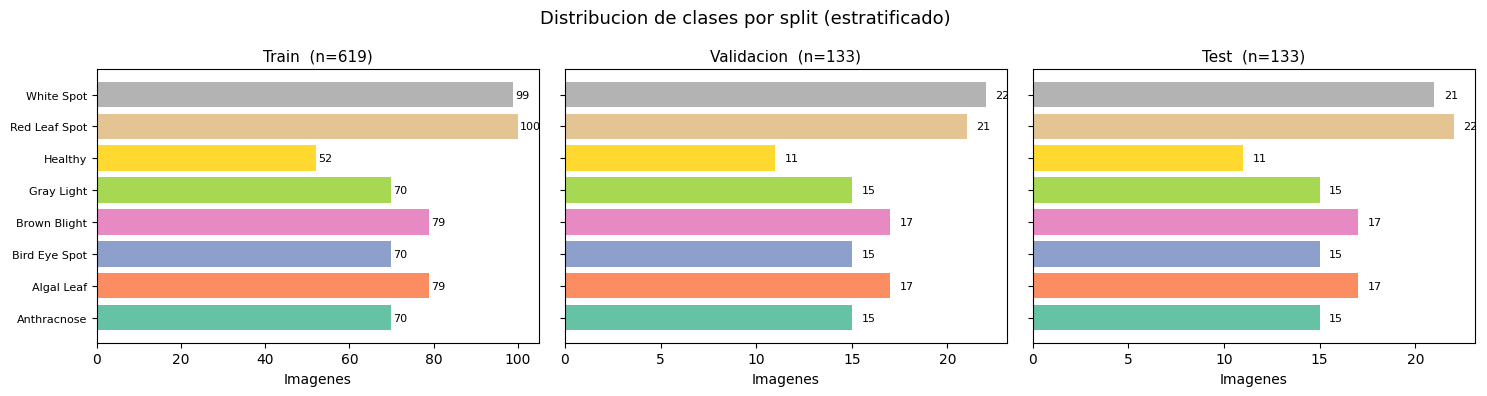

In [20]:
CLASS_TO_IDX       = {c: i for i, c in enumerate(sorted(set(all_labels)))}
IDX_TO_CLASS       = {i: c for c, i in CLASS_TO_IDX.items()}
CLASS_NAMES_SORTED = sorted(CLASS_TO_IDX.keys())

train_paths, temp_paths, train_labels, temp_labels = train_test_split(
    all_image_paths, all_labels,
    test_size=0.30, random_state=SEED, stratify=all_labels
)
val_paths, test_paths, val_labels, test_labels = train_test_split(
    temp_paths, temp_labels,
    test_size=0.50, random_state=SEED, stratify=temp_labels
)

print(f"Train: {len(train_paths)} | Val: {len(val_paths)} | Test: {len(test_paths)}")

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
colores   = plt.cm.Set2(np.linspace(0, 1, len(CLASS_NAMES_SORTED)))
for ax, (sname, slabels) in zip(
    axes, [("Train", train_labels), ("Validacion", val_labels), ("Test", test_labels)]
):
    counts = pd.Series(slabels).value_counts().sort_index()
    ax.barh(range(len(counts)), counts.values, color=colores[:len(counts)])
    ax.set_yticks(range(len(counts)))
    ax.set_yticklabels([c.replace("_", " ").title() for c in counts.index], fontsize=8)
    ax.set_title(f"{sname}  (n={len(slabels)})", fontsize=11)
    ax.set_xlabel("Imagenes")
    for i, v in enumerate(counts.values):
        ax.text(v + 0.5, i, str(v), va="center", fontsize=8)
plt.suptitle("Distribucion de clases por split (estratificado)", fontsize=13)
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/04_distribucion_splits.png", dpi=150, bbox_inches="tight")
plt.show()


### 2.2 Aumentacion de datos

La aumentacion se aplica **solo en train**. Aplicarla en validacion contaminaria la senal de evaluacion: el modelo se compararia contra versiones alteradas, haciendo que las curvas de perdida sean menos informativas y que EarlyStopping pierda precision.

Transformaciones elegidas para simular condiciones de campo abierto:

| Transformacion | Razon para campo abierto |
|---|---|
| Flip horizontal y vertical | Sin orientacion canonica al fotografiar hojas |
| Rotacion ±30 deg | Camara libre en mano del tecnico de campo |
| Zoom ±20% | Distancia variable hoja-camara |
| Contraste aleatorio | Variacion luz solar directa vs sombra |
| Brillo aleatorio | Iluminacion solar variable durante el dia |

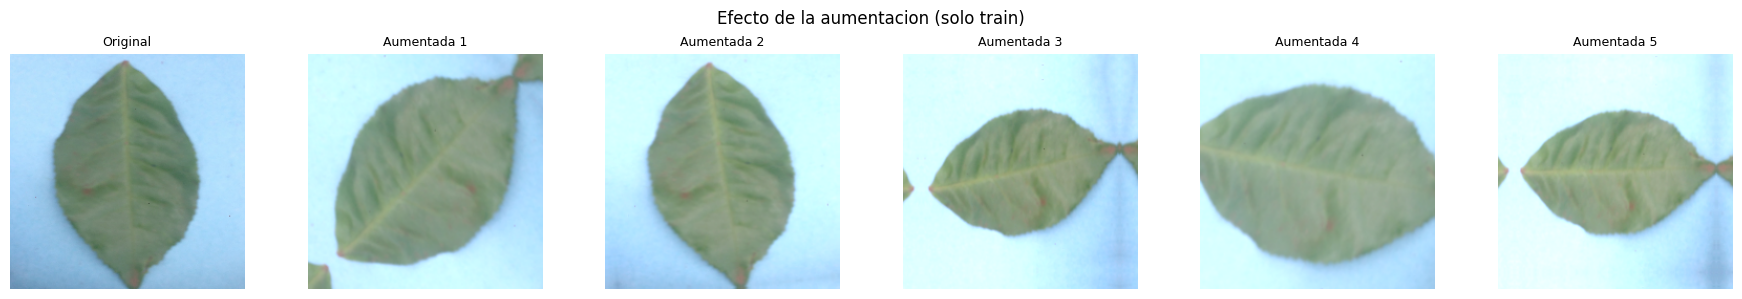

In [21]:
augmentation_layer = keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical", seed=SEED),
    layers.RandomRotation(0.30, seed=SEED),
    layers.RandomZoom(0.20,  seed=SEED),
    layers.RandomContrast(0.25, seed=SEED),
], name="augmentation")

def apply_brightness(img, label, max_delta=0.3):
    img = tf.image.random_brightness(img, max_delta=max_delta * 255)
    return tf.clip_by_value(img, 0.0, 255.0), label

# Visualizar efecto
random.seed(SEED)
orig = tf.io.read_file(random.choice(train_paths))
orig = tf.image.resize(tf.cast(
    tf.image.decode_image(orig, channels=3, expand_animations=False),
    tf.float32), [IMG_SIZE, IMG_SIZE])

fig, axes = plt.subplots(1, 6, figsize=(18, 3))
axes[0].imshow(orig.numpy().astype("uint8")); axes[0].set_title("Original", fontsize=9)
axes[0].axis("off")
tf.random.set_seed(SEED)
for k in range(5):
    aug = augmentation_layer(tf.expand_dims(orig, 0), training=True)[0]
    aug, _ = apply_brightness(aug, None)
    axes[k+1].imshow(aug.numpy().astype("uint8"))
    axes[k+1].set_title(f"Aumentada {k+1}", fontsize=9); axes[k+1].axis("off")
plt.suptitle("Efecto de la aumentacion (solo train)", fontsize=12)
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/05_augmentation_samples.png", dpi=150, bbox_inches="tight")
plt.show()


### 2.3 Pipeline tf.data

In [22]:
def load_image(path, label, img_size=IMG_SIZE):
    img = tf.io.read_file(path)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    img.set_shape([None, None, 3])
    img = tf.image.resize(img, [img_size, img_size])
    return tf.cast(img, tf.float32), label

def build_dataset(paths, labels_str, augment=False, shuffle=False,
                  batch_size=BATCH_SIZE):
    """
    Entrega imagenes en [0, 255] float32.
    El preprocess_input de cada backbone se aplica dentro del modelo (capa Lambda),
    no aqui. Esto permite reutilizar el mismo pipeline para todos los modelos.
    """
    label_idx  = [CLASS_TO_IDX[l] for l in labels_str]
    labels_ohe = tf.keras.utils.to_categorical(label_idx, num_classes=NUM_CLASSES)
    ds = tf.data.Dataset.from_tensor_slices((list(paths), labels_ohe))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(paths), seed=SEED, reshuffle_each_iteration=True)
    ds = ds.map(load_image, num_parallel_calls=AUTOTUNE)
    if augment:
        ds = ds.map(
            lambda x, y: (augmentation_layer(tf.expand_dims(x, 0), training=True)[0], y),
            num_parallel_calls=AUTOTUNE
        )
        ds = ds.map(apply_brightness, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(batch_size).prefetch(AUTOTUNE)
    return ds

ds_train = build_dataset(train_paths, train_labels, augment=True,  shuffle=True)
ds_val   = build_dataset(val_paths,   val_labels,   augment=False, shuffle=False)
ds_test  = build_dataset(test_paths,  test_labels,  augment=False, shuffle=False)

for name, ds in [("Train", ds_train), ("Val", ds_val), ("Test", ds_test)]:
    for x, y in ds.take(1):
        print(f"{name:5s} | shape: {tuple(x.shape)} | rango: [{x.numpy().min():.0f}, {x.numpy().max():.0f}]")


Train | shape: (32, 224, 224, 3) | rango: [0, 255]
Val   | shape: (32, 224, 224, 3) | rango: [0, 255]
Test  | shape: (32, 224, 224, 3) | rango: [0, 255]


---
## Bloque 3 – CNN Baseline (desde cero)

Red convolucional sin pesos preentrenados. Establece el piso de comparacion para evaluar el beneficio real del transfer learning. Con un dataset pequeno se espera desempeno bajo y convergencia lenta.

In [23]:
def build_baseline_cnn(img_size=IMG_SIZE, num_classes=NUM_CLASSES):
    return keras.Sequential([
        layers.Input(shape=(img_size, img_size, 3)),
        layers.Rescaling(1.0 / 255.0),
        layers.Conv2D(32, 3, padding="same", activation="relu"),
        layers.BatchNormalization(), layers.MaxPooling2D(),
        layers.Conv2D(64, 3, padding="same", activation="relu"),
        layers.BatchNormalization(), layers.MaxPooling2D(),
        layers.Conv2D(128, 3, padding="same", activation="relu"),
        layers.BatchNormalization(), layers.MaxPooling2D(),
        layers.Conv2D(256, 3, padding="same", activation="relu"),
        layers.BatchNormalization(), layers.GlobalAveragePooling2D(),
        layers.Dense(256, activation="relu"),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation="softmax"),
    ], name="cnn_baseline")

tf.keras.backend.clear_session()
baseline = build_baseline_cnn()
baseline.summary()
print(f"""
Parametros: {baseline.count_params():,}""")

Model: "cnn_baseline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │         2,056 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 458,184 (1.75 MB)

 Trainable params: 457,224 (1.74 MB)

 Non-trainable params: 960 (3.75 KB)


Parametros: 458,184


In [24]:
baseline, history_baseline, t_baseline_train = train_or_load(
    baseline, "baseline_best",
    ds_train, ds_val, ds_test,
    epochs=50, lr=1e-3, patience=8,
)


[DRIVE] Copiando baseline_best desde Drive...
[SKIP] baseline_best ya entrenado. Cargando desde disco...


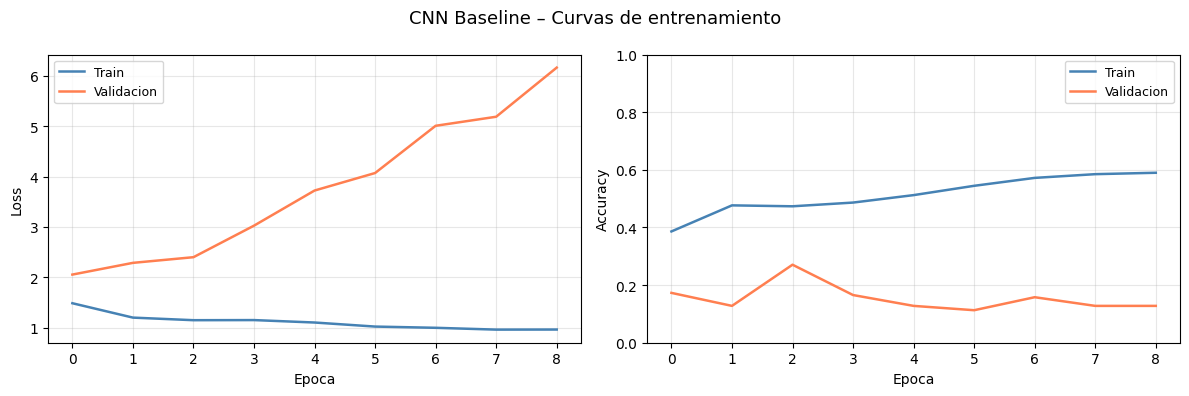

Baseline | Test accuracy: 0.2406 | Epocas: 9 | Inf: 124.2ms


In [25]:
def plot_history(history, title, save_path, ylim_acc=(0, 1)):
    h = history.history if hasattr(history, "history") else history
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    for ax, (mt, mv), ylabel in zip(
        axes,
        [('loss', 'val_loss'), ('accuracy', 'val_accuracy')],
        ["Loss", "Accuracy"]
    ):
        ax.plot(h[mt], label="Train",      color="steelblue", lw=1.8)
        ax.plot(h[mv], label="Validacion", color="coral",     lw=1.8)
        ax.set_xlabel("Epoca"); ax.set_ylabel(ylabel)
        ax.legend(fontsize=9); ax.grid(alpha=0.3)
        if mt == "accuracy":
            ax.set_ylim(ylim_acc)
    plt.suptitle(title, fontsize=13)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()

def measure_inference(model, ds, n_runs=50):
    sample_x = next(iter(ds.take(1)))[0][:1]
    _ = model.predict(sample_x, verbose=0)
    t0 = time.time()
    for _ in range(n_runs):
        model.predict(sample_x, verbose=0)
    return (time.time() - t0) / n_runs * 1000  # ms

plot_history(history_baseline,
             "CNN Baseline – Curvas de entrenamiento",
             f"{FIGURES_DIR}/06_baseline_curves.png")

# Compile the model if it was loaded (t_baseline_train == 0.0) and not trained
# (otherwise, train_or_load would have compiled it during training)
if t_baseline_train == 0.0:
    baseline.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss="categorical_crossentropy",
        metrics=["accuracy"],
    )

loss_b, acc_b = baseline.evaluate(ds_test, verbose=0)
epocas_b      = len(history_baseline.history["loss"])
t_inf_b       = measure_inference(baseline, ds_test)
print(f"Baseline | Test accuracy: {acc_b:.4f} | Epocas: {epocas_b} | Inf: {t_inf_b:.1f}ms")

results["CNN Baseline"] = {
    "params_total": baseline.count_params(), "params_trainable": baseline.count_params(),
    "accuracy_test": acc_b, "inf_ms": t_inf_b,
    "epocas": epocas_b, "train_min": t_baseline_train / 60,
}

---
## Bloque 4 – Transfer Learning – Extraccion de Caracteristicas

Backbone congelado (`trainable = False`): solo se entrena la cabeza. El `preprocess_input` de cada backbone se incluye como capa Lambda dentro del modelo, permitiendo reutilizar el mismo pipeline de datos para los tres.

| Backbone | Params aprox. | Perfil |
|---|---|---|
| **MobileNetV3Small** | ~2.5 M | Movil; SE-blocks + hard-swish |
| **EfficientNetB0**   | ~5.3 M | Movil; escalado compuesto |
| **ResNet50**         | ~25 M  | Referencia de capacidad maxima |

In [26]:
def get_backbone_from_model(model):
    """Localiza el backbone dentro del modelo sin depender del nombre de capa."""
    for layer in model.layers:
        if isinstance(layer, keras.Model) and layer.name != model.name:
            return layer
    raise ValueError("Backbone no encontrado.")

def build_feature_extractor(backbone_class, backbone_name, name,
                             num_classes=NUM_CLASSES, img_size=IMG_SIZE):
    """
    Modelo de feature extraction con backbone congelado.
    backbone_name: clave en PreprocessLayer._FN_MAP
                   ('mobilenet_v3' | 'efficientnet' | 'resnet50')
    Usa PreprocessLayer en lugar de Lambda para compatibilidad con Keras 3.x.
    """
    backbone = backbone_class(
        include_top=False, weights="imagenet",
        input_shape=(img_size, img_size, 3),
    )
    backbone.trainable = False

    inputs  = keras.Input(shape=(img_size, img_size, 3), name="input_img")
    x       = PreprocessLayer(backbone_name, name="preprocess")(inputs)
    x       = backbone(x, training=False)
    x       = layers.GlobalAveragePooling2D(name="gap")(x)
    x       = layers.Dense(256, activation="relu", name="fc_256")(x)
    x       = layers.Dropout(0.30, name="dropout")(x)
    outputs = layers.Dense(num_classes, activation="softmax", name="predictions")(x)

    model       = keras.Model(inputs, outputs, name=name)
    total_p     = model.count_params()
    trainable_p = sum(tf.keras.backend.count_params(w) for w in model.trainable_weights)
    print(f"{name}: total={total_p:,}  trainable={trainable_p:,}  frozen={total_p-trainable_p:,}")
    return model, total_p, trainable_p


#### 4.A – MobileNetV3Small (Feature Extraction)

4334752/4334752 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
MobileNetV3Small_FE: total=1,088,888  trainable=149,768  frozen=939,120
[DRIVE] Copiando mob_fe_best desde Drive...
[SKIP] mob_fe_best ya entrenado. Cargando desde disco...


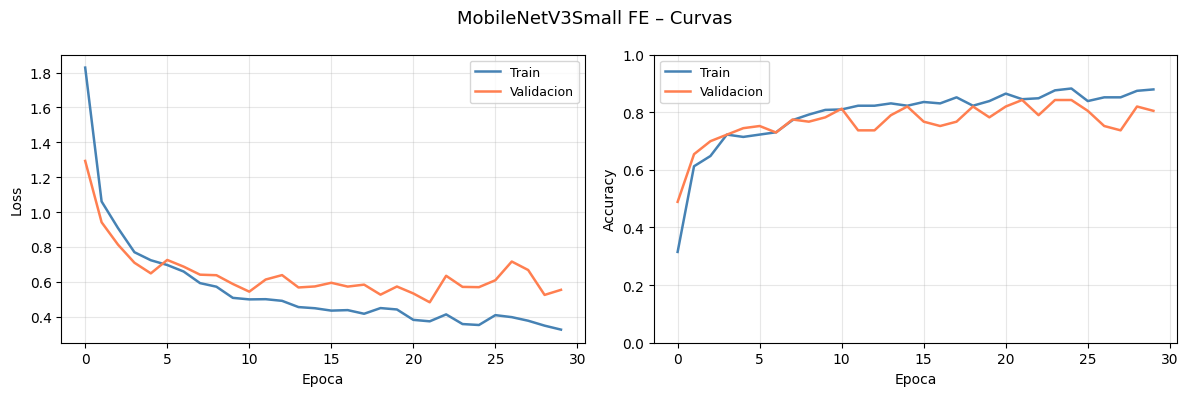

MobV3Small FE | acc: 0.8421 | inf: 140.8ms


In [27]:
gc.collect(); tf.keras.backend.clear_session()

mob_fe, mob_total, mob_trainable = build_feature_extractor(
    MobileNetV3Small, "mobilenet_v3", "MobileNetV3Small_FE"
)
mob_fe, history_mob_fe, t_mob_fe = train_or_load(
    mob_fe, "mob_fe_best",
    ds_train, ds_val, ds_test, epochs=30, lr=1e-3, patience=8,
)
plot_history(history_mob_fe, "MobileNetV3Small FE – Curvas",
             f"{FIGURES_DIR}/07_mobv3_fe_curves.png")
_, acc_mob_fe = mob_fe.evaluate(ds_test, verbose=0)
epocas_mob_fe = len(history_mob_fe.history["loss"])
t_inf_mob_fe  = measure_inference(mob_fe, ds_test)
print(f"MobV3Small FE | acc: {acc_mob_fe:.4f} | inf: {t_inf_mob_fe:.1f}ms")
results["MobileNetV3Small FE"] = {
    "params_total": mob_total, "params_trainable": mob_trainable,
    "accuracy_test": acc_mob_fe, "inf_ms": t_inf_mob_fe,
    "epocas": epocas_mob_fe, "train_min": t_mob_fe / 60,
}

#### 4.B – EfficientNetB0 (Feature Extraction)

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
EfficientNetB0_FE: total=4,379,563  trainable=329,992  frozen=4,049,571
[DRIVE] Copiando eff_fe_best desde Drive...
[SKIP] eff_fe_best ya entrenado. Cargando desde disco...


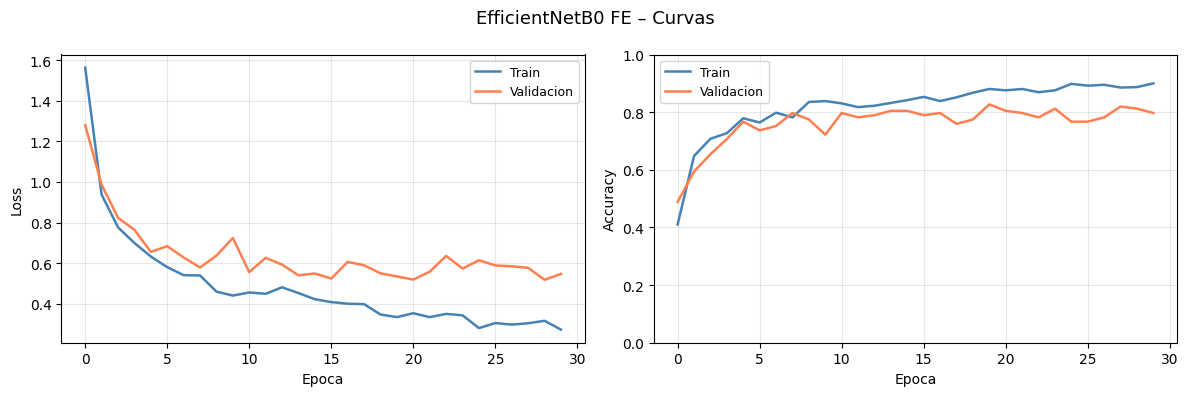

EfficientNetB0 FE | acc: 0.8195 | inf: 158.5ms


In [28]:
gc.collect(); tf.keras.backend.clear_session()

eff_fe, eff_total, eff_trainable = build_feature_extractor(
    EfficientNetB0, "efficientnet", "EfficientNetB0_FE"
)
eff_fe, history_eff_fe, t_eff_fe = train_or_load(
    eff_fe, "eff_fe_best",
    ds_train, ds_val, ds_test, epochs=30, lr=1e-3, patience=8,
)
plot_history(history_eff_fe, "EfficientNetB0 FE – Curvas",
             f"{FIGURES_DIR}/08_effb0_fe_curves.png")
_, acc_eff_fe = eff_fe.evaluate(ds_test, verbose=0)
epocas_eff_fe = len(history_eff_fe.history["loss"])
t_inf_eff_fe  = measure_inference(eff_fe, ds_test)
print(f"EfficientNetB0 FE | acc: {acc_eff_fe:.4f} | inf: {t_inf_eff_fe:.1f}ms")
results["EfficientNetB0 FE"] = {
    "params_total": eff_total, "params_trainable": eff_trainable,
    "accuracy_test": acc_eff_fe, "inf_ms": t_inf_eff_fe,
    "epocas": epocas_eff_fe, "train_min": t_eff_fe / 60,
}

#### 4.C – ResNet50 (Feature Extraction)

ResNet50_FE: total=24,114,312  trainable=526,600  frozen=23,587,712
[RESUME] res_fe_best: reanudando desde epoca 5...
Epoch 6/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 192s 9s/step - accuracy: 0.7625 - loss: 0.6004 - val_accuracy: 0.8195 - val_loss: 0.6433
Epoch 7/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 208s 9s/step - accuracy: 0.7851 - loss: 0.5729 - val_accuracy: 0.8271 - val_loss: 0.6290
Epoch 8/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 198s 9s/step - accuracy: 0.7932 - loss: 0.5654 - val_accuracy: 0.8271 - val_loss: 0.5747
Epoch 9/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 202s 9s/step - accuracy: 0.7803 - loss: 0.5478 - val_accuracy: 0.8045 - val_loss: 0.6316
Epoch 10/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 207s 9s/step - accuracy: 0.8029 - loss: 0.4996 - val_accuracy: 0.7744 - val_loss: 0.6530
Epoch 11/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 185s 9s/step - accuracy: 0.7964 - loss: 0.4832 - val_accuracy: 0.8120 - val_loss: 0.6113
Epoch 12/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 200s 9s/step - accuracy: 0.8142 - loss: 0.4525 - val_accuracy: 0.7820 - val_los

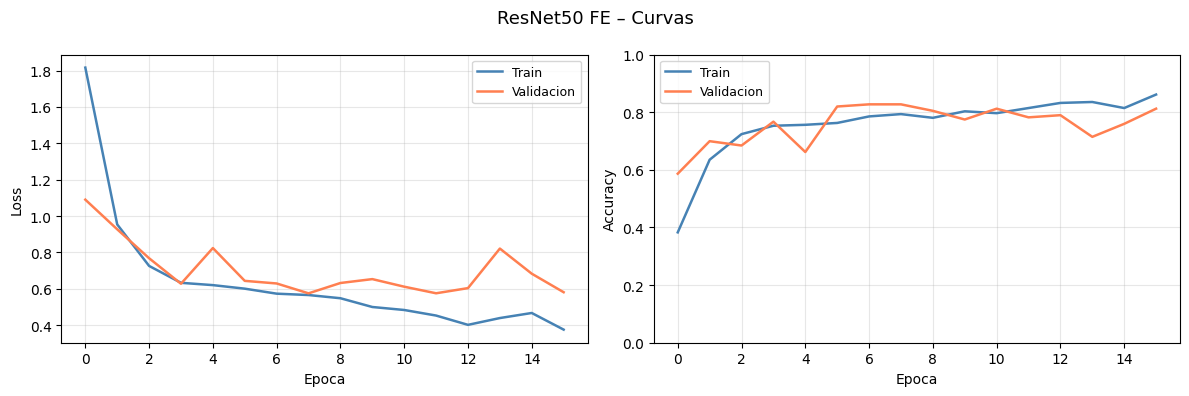

ResNet50 FE | acc: 0.7970 | inf: 344.5ms


In [30]:
gc.collect(); tf.keras.backend.clear_session()

res_fe, res_total, res_trainable = build_feature_extractor(
    ResNet50, "resnet50", "ResNet50_FE"
)
res_fe, history_res_fe, t_res_fe = train_or_load(
    res_fe, "res_fe_best",
    ds_train, ds_val, ds_test, epochs=30, lr=1e-3, patience=8,
)
plot_history(history_res_fe, "ResNet50 FE – Curvas",
             f"{FIGURES_DIR}/09_resnet50_fe_curves.png")
_, acc_res_fe = res_fe.evaluate(ds_test, verbose=0)
epocas_res_fe = len(history_res_fe.history["loss"])
t_inf_res_fe  = measure_inference(res_fe, ds_test)
print(f"ResNet50 FE | acc: {acc_res_fe:.4f} | inf: {t_inf_res_fe:.1f}ms")
results["ResNet50 FE"] = {
    "params_total": res_total, "params_trainable": res_trainable,
    "accuracy_test": acc_res_fe, "inf_ms": t_inf_res_fe,
    "epocas": epocas_res_fe, "train_min": t_res_fe / 60,
}

---
## Bloque 5 – Fine-Tuning

Estrategia en dos etapas: primero la cabeza converge con backbone congelado (Bloque 4), luego se descongelan las ultimas N capas del backbone con LR mucho menor para no sobrescribir los pesos de ImageNet.

### 5.1 MobileNetV3Small – Fine-Tuning (ultimas 20 capas)

Descongeladas: 20 | Entrenables: 496,664 / 1,088,888
[DRIVE] Copiando mob_ft_best desde Drive...
[SKIP] mob_ft_best ya entrenado. Cargando desde disco...


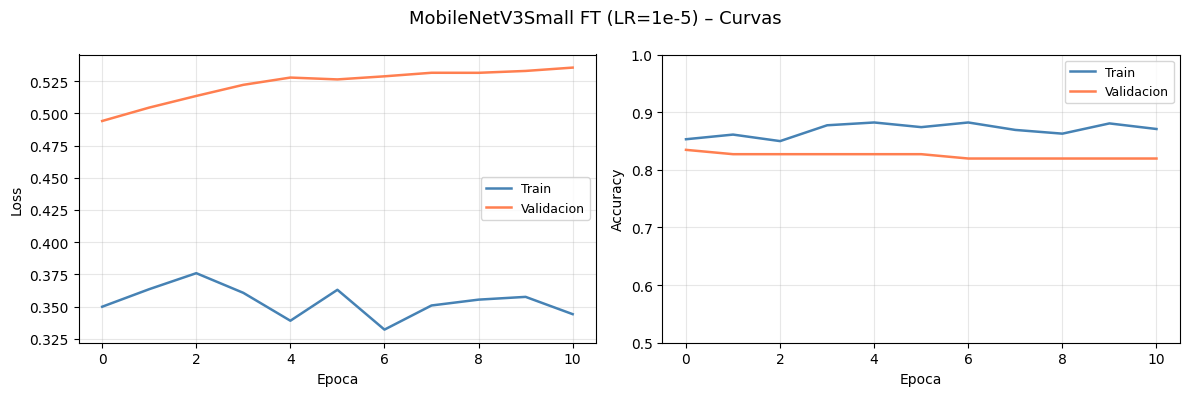

MobV3Small FT | acc: 0.8421 | inf: 134.6ms


In [34]:
mob_ft = load_keras_model(f"{MODELS_DIR}/mob_fe_best.keras", compile=False)

backbone_mob = get_backbone_from_model(mob_ft)
N_UNFREEZE   = 20
backbone_mob.trainable = True
for layer in backbone_mob.layers[:-N_UNFREEZE]:
    layer.trainable = False
for layer in backbone_mob.layers:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False

total_mob_ft     = mob_ft.count_params()
trainable_mob_ft = sum(tf.keras.backend.count_params(w) for w in mob_ft.trainable_weights)
print(f"Descongeladas: {N_UNFREEZE} | Entrenables: {trainable_mob_ft:,} / {total_mob_ft:,}")

mob_ft, history_mob_ft, t_mob_ft = train_or_load(
    mob_ft, "mob_ft_best",
    ds_train, ds_val, ds_test,
    epochs=40, lr=1e-5, patience=10, reduce_lr=True,
)
plot_history(history_mob_ft, "MobileNetV3Small FT (LR=1e-5) – Curvas",
             f"{FIGURES_DIR}/10_mobv3_ft_curves.png", ylim_acc=(0.5, 1.0))

_, acc_mob_ft = mob_ft.evaluate(ds_test, verbose=0)
epocas_mob_ft = len(history_mob_ft.history["loss"])
t_inf_mob_ft  = measure_inference(mob_ft, ds_test)
print(f"MobV3Small FT | acc: {acc_mob_ft:.4f} | inf: {t_inf_mob_ft:.1f}ms")
results["MobileNetV3Small FT"] = {
    "params_total": total_mob_ft, "params_trainable": trainable_mob_ft,
    "accuracy_test": acc_mob_ft, "inf_ms": t_inf_mob_ft,
    "epocas": epocas_mob_ft, "train_min": t_mob_ft / 60,
}


### 5.2 Experimento: backbone completamente descongelado con LR alta

Este experimento replica intencionalmente el error mas comun: aplicar fine-tuning con LR alta (1e-3) sobre todo el backbone desde el inicio, sin la etapa previa de entrenamiento de cabeza. El resultado esperado es inestabilidad en las curvas (*catastrophic forgetting* de los pesos de ImageNet).

In [1]:
gc.collect(); tf.keras.backend.clear_session()
mob_dest, _, _ = build_feature_extractor(MobileNetV3Small, "mobilenet_v3", "Destructivo_FE")
for layer in mob_dest.layers:
    layer.trainable = True
trainable_dest = sum(tf.keras.backend.count_params(w) for w in mob_dest.trainable_weights)
print(f"Params entrenables (destructivo): {trainable_dest:,}")

mob_dest.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="categorical_crossentropy", metrics=["accuracy"],
)
t0 = time.time()
history_dest = mob_dest.fit(ds_train, validation_data=ds_val, epochs=20, verbose=1)
t_dest = time.time() - t0

plot_history(history_dest, "Destructivo – MobileNetV3Small completo LR=1e-3",
             f"{FIGURES_DIR}/11_destructive_experiment.png")
_, acc_dest = mob_dest.evaluate(ds_test, verbose=0)
print(f"Destructivo | acc: {acc_dest:.4f}  (comparar con FT etapas: {acc_mob_ft:.4f})")
del mob_dest; gc.collect(); tf.keras.backend.clear_session()


NameError: name 'gc' is not defined

### 5.3 ResNet50 – Fine-Tuning (ultimas 20 capas)

In [ ]:
res_ft = load_keras_model(f"{MODELS_DIR}/res_fe_best.keras", compile=False)

backbone_res = get_backbone_from_model(res_ft)
N_UNFREEZE_R = 20
backbone_res.trainable = True
for layer in backbone_res.layers[:-N_UNFREEZE_R]:
    layer.trainable = False
for layer in backbone_res.layers:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False

total_res_ft     = res_ft.count_params()
trainable_res_ft = sum(tf.keras.backend.count_params(w) for w in res_ft.trainable_weights)
print(f"Descongeladas: {N_UNFREEZE_R} | Entrenables: {trainable_res_ft:,} / {total_res_ft:,}")

res_ft, history_res_ft, t_res_ft = train_or_load(
    res_ft, "res_ft_best",
    ds_train, ds_val, ds_test,
    epochs=40, lr=1e-5, patience=10, reduce_lr=True,
)
plot_history(history_res_ft, "ResNet50 FT (LR=1e-5) – Curvas",
             f"{FIGURES_DIR}/12_resnet50_ft_curves.png", ylim_acc=(0.5, 1.0))

_, acc_res_ft = res_ft.evaluate(ds_test, verbose=0)
epocas_res_ft = len(history_res_ft.history["loss"])
t_inf_res_ft  = measure_inference(res_ft, ds_test)
print(f"ResNet50 FT | acc: {acc_res_ft:.4f} | inf: {t_inf_res_ft:.1f}ms")
results["ResNet50 FT"] = {
    "params_total": total_res_ft, "params_trainable": trainable_res_ft,
    "accuracy_test": acc_res_ft, "inf_ms": t_inf_res_ft,
    "epocas": epocas_res_ft, "train_min": t_res_ft / 60,
}


---
## Bloque 6 – Comparativa General de Modelos

In [ ]:
df_results = pd.DataFrame(results).T.reset_index()
df_results.columns = [
    "Modelo", "Params totales", "Params entrenables",
    "Accuracy Test", "Inferencia (ms)", "Epocas", "Entrenamiento (min)"
]
df_disp = df_results.copy()
df_disp["Params totales"]      = df_disp["Params totales"].apply(lambda x: f"{int(x):,}")
df_disp["Params entrenables"]  = df_disp["Params entrenables"].apply(lambda x: f"{int(x):,}")
df_disp["Accuracy Test"]       = df_disp["Accuracy Test"].apply(lambda x: f"{x*100:.2f}%")
df_disp["Inferencia (ms)"]     = df_disp["Inferencia (ms)"].apply(lambda x: f"{x:.1f}")
df_disp["Epocas"]              = df_disp["Epocas"].astype(int)
df_disp["Entrenamiento (min)"] = df_disp["Entrenamiento (min)"].apply(lambda x: f"{x:.1f}")
print(df_disp.to_string(index=False))

modelos    = df_results["Modelo"].tolist()
accuracies = [v * 100 for v in df_results["Accuracy Test"].tolist()]
inf_times  = df_results["Inferencia (ms)"].tolist()
palette    = ["#b0c4de","#6495ed","#4169e1","#98fb98","#32cd32","#ffa07a","#ff4500"]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
bars1 = axes[0].bar(modelos, accuracies, color=palette[:len(modelos)], edgecolor="black", lw=0.5)
for bar, v in zip(bars1, accuracies):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.4,
                 f"{v:.1f}%", ha="center", va="bottom", fontsize=8)
axes[0].axhline(100/NUM_CLASSES, color="crimson", ls="--", lw=1, alpha=0.6,
                label=f"Azar ({100/NUM_CLASSES:.1f}%)")
axes[0].set_ylabel("Accuracy (%)"); axes[0].set_title("Accuracy en test")
axes[0].set_ylim(0, 112); axes[0].legend(); axes[0].tick_params(axis="x", rotation=40)

bars2 = axes[1].bar(modelos, inf_times, color=palette[:len(modelos)], edgecolor="black", lw=0.5)
for bar, v in zip(bars2, inf_times):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+5,
                 f"{v:.0f}", ha="center", va="bottom", fontsize=8)
axes[1].axhline(2000, color="crimson", ls="--", lw=1.4, label="Limite 2s")
axes[1].set_ylabel("Inferencia (ms)"); axes[1].set_title("Tiempo de inferencia")
axes[1].legend(); axes[1].tick_params(axis="x", rotation=40)

plt.suptitle("Comparativa general de modelos", fontsize=13)
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/13_comparativa_modelos.png", dpi=150, bbox_inches="tight")
plt.show()


---
## Bloque 7 – Analisis de Errores

In [ ]:
best_name = max(results, key=lambda k: results[k]["accuracy_test"])
print(f"Mejor modelo: {best_name}  ({results[best_name]['accuracy_test']*100:.2f}%)")

model_paths_map = {
    "CNN Baseline":        f"{MODELS_DIR}/baseline_best.keras",
    "MobileNetV3Small FE": f"{MODELS_DIR}/mob_fe_best.keras",
    "EfficientNetB0 FE":   f"{MODELS_DIR}/eff_fe_best.keras",
    "ResNet50 FE":         f"{MODELS_DIR}/res_fe_best.keras",
    "MobileNetV3Small FT": f"{MODELS_DIR}/mob_ft_best.keras",
    "ResNet50 FT":         f"{MODELS_DIR}/res_ft_best.keras",
}
best_model = load_keras_model(model_paths_map[best_name], compile=False)

y_true_idx, y_pred_idx = [], []
for x_batch, y_batch in ds_test:
    preds = best_model.predict(x_batch, verbose=0)
    y_pred_idx.extend(np.argmax(preds, axis=1))
    y_true_idx.extend(np.argmax(y_batch.numpy(), axis=1))
y_true_idx = np.array(y_true_idx)
y_pred_idx = np.array(y_pred_idx)
print(f"Test samples: {len(y_true_idx)} | Acc: {(y_true_idx==y_pred_idx).mean():.4f}")


### 7.1 Matriz de confusion

In [ ]:
cm      = confusion_matrix(y_true_idx, y_pred_idx)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
class_labels = [IDX_TO_CLASS[i].replace("_", " ").title() for i in range(NUM_CLASSES)]

fig, axes = plt.subplots(1, 2, figsize=(17, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_labels, yticklabels=class_labels,
            linewidths=0.4, ax=axes[0])
axes[0].set_title("Absoluta"); axes[0].set_xlabel("Prediccion"); axes[0].set_ylabel("Real")
axes[0].tick_params(axis="x", rotation=40, labelsize=8)
axes[0].tick_params(axis="y", rotation=0,  labelsize=8)

sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues",
            xticklabels=class_labels, yticklabels=class_labels,
            linewidths=0.4, vmin=0, vmax=1, ax=axes[1])
axes[1].set_title("Normalizada por fila (recall)")
axes[1].set_xlabel("Prediccion"); axes[1].set_ylabel("Real")
axes[1].tick_params(axis="x", rotation=40, labelsize=8)
axes[1].tick_params(axis="y", rotation=0,  labelsize=8)

plt.suptitle(f"Matriz de confusion – {best_name}", fontsize=13)
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/14_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

pairs = [(cm[i,j], class_labels[i], class_labels[j])
         for i in range(NUM_CLASSES) for j in range(NUM_CLASSES) if i!=j and cm[i,j]>0]
pairs.sort(reverse=True)
print("Pares mas confundidos (real -> predicho):")
for cnt, r, p in pairs[:6]:
    print(f"  {r:30s} -> {p:30s}: {int(cnt)}")


### 7.2 F1 por clase

In [ ]:
report_str  = classification_report(y_true_idx, y_pred_idx,
                                     target_names=class_labels, digits=3)
report_dict = classification_report(y_true_idx, y_pred_idx,
                                     target_names=class_labels, output_dict=True)
print(report_str)

f1_scores = {cls: report_dict[cls]["f1-score"] for cls in class_labels if cls in report_dict}
sorted_f1  = sorted(f1_scores.items(), key=lambda x: x[1])
colors_f1  = ["#d32f2f" if f < 0.60 else "#f57c00" if f < 0.75 else "#388e3c"
               for _, f in sorted_f1]
fig, ax = plt.subplots(figsize=(10, 4))
ax.barh([c for c, _ in sorted_f1], [f for _, f in sorted_f1],
        color=colors_f1, edgecolor="black", lw=0.4)
ax.axvline(0.60, color="crimson",    ls="--", lw=1, alpha=0.7, label="0.60")
ax.axvline(0.75, color="darkorange", ls="--", lw=1, alpha=0.7, label="0.75")
ax.set_xlabel("F1-score"); ax.set_title("F1-score por clase")
ax.legend(fontsize=9); ax.set_xlim(0, 1.05)
for i, (_, f) in enumerate(sorted_f1):
    ax.text(f+0.01, i, f"{f:.3f}", va="center", fontsize=8)
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/15_f1_por_clase.png", dpi=150, bbox_inches="tight")
plt.show()


### 7.3 Ejemplos mal clasificados

In [ ]:

test_paths_arr = np.array(test_paths)
wrong_mask     = (y_true_idx != y_pred_idx)
wrong_paths    = test_paths_arr[wrong_mask]
wrong_true     = y_true_idx[wrong_mask]
wrong_pred     = y_pred_idx[wrong_mask]

n_show = min(12, len(wrong_paths))
random.seed(SEED)
sample_idx = random.sample(range(len(wrong_paths)), n_show)

fig, axes = plt.subplots(3, 4, figsize=(14, 10))
axes = axes.flatten()
for k, idx in enumerate(sample_idx):
    img  = Image.open(wrong_paths[idx]).convert("RGB").resize((IMG_SIZE, IMG_SIZE))
    real = IDX_TO_CLASS[wrong_true[idx]].replace("_", " ").title()
    pred = IDX_TO_CLASS[wrong_pred[idx]].replace("_", " ").title()
    axes[k].imshow(img)
    axes[k].set_title(f"Real: {real}\nPred: {pred}", fontsize=7, color="darkred")
    axes[k].axis("off")
for k in range(n_show, len(axes)):
    axes[k].axis("off")
plt.suptitle(f"Clasificaciones incorrectas – {best_name}", fontsize=12)
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/16_error_examples.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Incorrectas: {wrong_mask.sum()} / {len(y_true_idx)} ({wrong_mask.mean()*100:.1f}%)")

---
## Bloque 8 – Clasificacion Binaria (sana vs enferma)

Reformulacion del problema: `healthy` = clase 0, cualquier enfermedad = clase 1. Permite un sistema de triaje rapido en campo: identificar primero las hojas que requieren atencion, luego derivar al clasificador multiclase.

**Gana**: mayor robustez (mas imagenes por clase, menos efecto del desbalance). **Pierde**: no informa el tipo especifico de enfermedad, necesario para elegir tratamiento.

In [ ]:
def to_binary(label_str): return 0 if label_str == "healthy" else 1

train_labels_bin = [to_binary(l) for l in train_labels]
val_labels_bin   = [to_binary(l) for l in val_labels]
test_labels_bin  = [to_binary(l) for l in test_labels]

print("Distribucion binaria:")
for split, lbls in [("Train", train_labels_bin), ("Val", val_labels_bin), ("Test", test_labels_bin)]:
    n0 = lbls.count(0); n1 = lbls.count(1)
    print(f"  {split:5s}: healthy={n0} ({n0/len(lbls)*100:.1f}%) | enfermo={n1} ({n1/len(lbls)*100:.1f}%)")

def build_dataset_binary(paths, labels_int, augment=False, shuffle=False, batch_size=BATCH_SIZE):
    ds = tf.data.Dataset.from_tensor_slices((list(paths), [float(l) for l in labels_int]))
    if shuffle:
        ds = ds.shuffle(len(paths), seed=SEED, reshuffle_each_iteration=True)
    ds = ds.map(load_image, num_parallel_calls=AUTOTUNE)
    if augment:
        ds = ds.map(lambda x, y: (augmentation_layer(tf.expand_dims(x, 0), training=True)[0], y),
                    num_parallel_calls=AUTOTUNE)
        ds = ds.map(apply_brightness, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(batch_size).prefetch(AUTOTUNE)
    return ds

ds_train_bin = build_dataset_binary(train_paths, train_labels_bin, augment=True, shuffle=True)
ds_val_bin   = build_dataset_binary(val_paths,   val_labels_bin)
ds_test_bin  = build_dataset_binary(test_paths,  test_labels_bin)


In [ ]:
gc.collect(); tf.keras.backend.clear_session()

bin_backbone = MobileNetV3Small(
    include_top=False, weights="imagenet", input_shape=(IMG_SIZE, IMG_SIZE, 3)
)
bin_backbone.trainable = True
for layer in bin_backbone.layers[:-20]:
    layer.trainable = False
for layer in bin_backbone.layers:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False

inputs_bin  = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x_bin       = PreprocessLayer("mobilenet_v3", name="preprocess")(inputs_bin)
x_bin       = bin_backbone(x_bin, training=False)
x_bin       = layers.GlobalAveragePooling2D()(x_bin)
x_bin       = layers.Dense(128, activation="relu")(x_bin)
x_bin       = layers.Dropout(0.3)(x_bin)
out_bin     = layers.Dense(1, activation="sigmoid", name="binary_out")(x_bin)
binary_model = keras.Model(inputs_bin, out_bin, name="MobileNetV3Small_Binary")

binary_hist_path = f"{MODELS_DIR}/binary_best_history.json"
binary_path      = f"{MODELS_DIR}/binary_best.keras"
binary_ckpt_dir  = f"{MODELS_DIR}/binary_best_ckpts"
drive_bin_path   = f"{DRIVE_MODELS_DIR}/binary_best.keras"        if USE_DRIVE else None
drive_bin_hist   = f"{DRIVE_MODELS_DIR}/binary_best_history.json" if USE_DRIVE else None

if not os.path.exists(binary_path) and USE_DRIVE and drive_bin_path and os.path.exists(drive_bin_path):
    shutil.copy(drive_bin_path, binary_path)
    if drive_bin_hist and os.path.exists(drive_bin_hist):
        shutil.copy(drive_bin_hist, binary_hist_path)

if os.path.exists(binary_path) and os.path.exists(binary_hist_path):
    print("[SKIP] Clasificador binario ya entrenado. Cargando...")
    binary_model = load_keras_model(binary_path, compile=True)
    with open(binary_hist_path) as f:
        history_bin = HistoryLike(json.load(f))
    t_bin = 0.0
else:
    binary_model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-5),
        loss="binary_crossentropy",
        metrics=["accuracy",
                 tf.keras.metrics.Precision(name="precision"),
                 tf.keras.metrics.Recall(name="recall"),
                 tf.keras.metrics.AUC(name="auc")],
    )
    os.makedirs(binary_ckpt_dir, exist_ok=True)
    cbs_bin = [
        EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True, verbose=1),
        ModelCheckpoint(binary_path, monitor="val_auc", mode="max", save_best_only=True, verbose=0),
        EpochCheckpointCallback(binary_ckpt_dir, save_freq=5,
                                drive_dir=DRIVE_MODELS_DIR if USE_DRIVE else None,
                                model_name="binary_best"),
    ]
    if USE_DRIVE and drive_bin_path:
        cbs_bin.append(DriveBackupCallback(binary_path, drive_bin_path))

    t0 = time.time()
    history_bin_raw = binary_model.fit(
        ds_train_bin, validation_data=ds_val_bin, epochs=40, callbacks=cbs_bin, verbose=1,
    )
    t_bin = time.time() - t0
    with open(binary_hist_path, "w") as f:
        json.dump(history_bin_raw.history, f)
    if USE_DRIVE and drive_bin_hist:
        shutil.copy(binary_hist_path, drive_bin_hist)

    for ckpt in Path(binary_ckpt_dir).glob("epoch_*.keras"):
        ckpt.unlink()
    hist_p = os.path.join(binary_ckpt_dir, "history_partial.json")
    if os.path.exists(hist_p):
        os.remove(hist_p)

    history_bin = history_bin_raw

plot_history(history_bin, "Clasificador Binario – Curvas",
             f"{FIGURES_DIR}/17_binary_curves.png", ylim_acc=(0.5, 1.0))


In [ ]:
binary_model_loaded = load_keras_model(binary_path, compile=False)
binary_model_loaded.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss="binary_crossentropy",
    metrics=["accuracy",
             tf.keras.metrics.Precision(name="precision"),
             tf.keras.metrics.Recall(name="recall"),
             tf.keras.metrics.AUC(name="auc")],
)
bin_metrics = binary_model_loaded.evaluate(ds_test_bin, verbose=0)
bin_loss, bin_acc, bin_prec, bin_rec, bin_auc = bin_metrics
bin_f1 = 2 * bin_prec * bin_rec / (bin_prec + bin_rec + 1e-9)

print(f"Binario | Accuracy: {bin_acc*100:.2f}% | Precision: {bin_prec:.4f} | "
      f"Recall: {bin_rec:.4f} | F1: {bin_f1:.4f} | AUC: {bin_auc:.4f}")

y_bin_true, y_bin_pred = [], []
for x_batch, y_batch in ds_test_bin:
    preds = (binary_model_loaded.predict(x_batch, verbose=0).flatten() > 0.5).astype(int)
    y_bin_pred.extend(preds); y_bin_true.extend(y_batch.numpy().astype(int))

cm_bin = confusion_matrix(y_bin_true, y_bin_pred)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm_bin, annot=True, fmt="d", cmap="Greens",
            xticklabels=["Healthy", "Enfermo"],
            yticklabels=["Healthy", "Enfermo"], linewidths=0.5, ax=ax)
ax.set_xlabel("Prediccion"); ax.set_ylabel("Real")
ax.set_title(f"Confusion Binaria | Acc={bin_acc*100:.2f}% F1={bin_f1:.3f} AUC={bin_auc:.3f}")
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/18_binary_confusion.png", dpi=150, bbox_inches="tight")
plt.show()


---
## Bloque 9 – Estimacion de Viabilidad en Tablet

In [ ]:
THRESHOLD_MS = 2000
model_files  = {
    "CNN Baseline":        f"{MODELS_DIR}/baseline_best.keras",
    "MobileNetV3Small FE": f"{MODELS_DIR}/mob_fe_best.keras",
    "EfficientNetB0 FE":   f"{MODELS_DIR}/eff_fe_best.keras",
    "ResNet50 FE":         f"{MODELS_DIR}/res_fe_best.keras",
    "MobileNetV3Small FT": f"{MODELS_DIR}/mob_ft_best.keras",
    "ResNet50 FT":         f"{MODELS_DIR}/res_ft_best.keras",
    "Binario MobV3Small":  f"{MODELS_DIR}/binary_best.keras",
}
tablet_results = {}
sample_x = next(iter(ds_test.take(1)))[0][:1]

print(f"{'Modelo':<25} {'Inf(ms)':>9} {'Tamanio(MB)':>12} {'Estado':>14}")
print("-" * 65)
for name, path in model_files.items():
    if not os.path.exists(path):
        print(f"{name:<25} {'NO ENCONTRADO':>14}"); continue
    mdl     = load_keras_model(path, compile=False)
    size_mb = os.path.getsize(path) / (1024**2)
    _       = mdl.predict(sample_x, verbose=0)
    t0      = time.time()
    for _   in range(50): mdl.predict(sample_x, verbose=0)
    inf_ms  = (time.time() - t0) / 50 * 1000
    status  = "CUMPLE" if inf_ms < THRESHOLD_MS else "EXCEDE"
    tablet_results[name] = {"inf_ms": inf_ms, "size_mb": size_mb}
    print(f"{name:<25} {inf_ms:>9.1f} {size_mb:>12.1f} {status:>14}")
    del mdl; gc.collect(); tf.keras.backend.clear_session()


In [33]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
names_t   = list(tablet_results.keys())
inf_vals  = [tablet_results[n]["inf_ms"]  for n in names_t]
size_vals = [tablet_results[n]["size_mb"] for n in names_t]
pal_v     = ["#4caf50" if v < THRESHOLD_MS else "#f44336" for v in inf_vals]

bars1 = axes[0].bar(names_t, inf_vals, color=pal_v, edgecolor="black", lw=0.4)
axes[0].axhline(THRESHOLD_MS, color="crimson", ls="--", lw=1.5, label="Limite 2s")
for bar, v in zip(bars1, inf_vals):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+10,
                 f"{v:.0f}", ha="center", va="bottom", fontsize=8)
axes[0].set_ylabel("Tiempo de inferencia (ms)")
axes[0].set_title("Inferencia por imagen"); axes[0].legend()
axes[0].tick_params(axis="x", rotation=40, labelsize=8)

axes[1].bar(names_t, size_vals, color="#2196F3", edgecolor="black", lw=0.4)
for i, v in enumerate(size_vals):
    axes[1].text(i, v+0.3, f"{v:.1f}MB", ha="center", va="bottom", fontsize=8)
axes[1].set_ylabel("Tamano en disco (MB)")
axes[1].set_title("Tamano del modelo"); axes[1].tick_params(axis="x", rotation=40, labelsize=8)

plt.suptitle("Viabilidad en dispositivo movil", fontsize=13)
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/19_tablet_viability.png", dpi=150, bbox_inches="tight")
plt.show()

print("""
Para produccion: convertir con tf.lite.TFLiteConverter + cuantizacion int8
reduce tamano x4 y acelera inferencia en CPUs ARM (NNAPI / Core ML).""")

SyntaxError: unterminated string literal (detected at line 27) (2758629227.py, line 27)

---
## Exportacion de figuras

In [31]:
zip_path = "/content/figuras_experiencia1"
shutil.make_archive(zip_path, "zip", FIGURES_DIR)

if USE_DRIVE:
    shutil.copy(f"{zip_path}.zip", f"{DRIVE_MODELS_DIR}/figuras_experiencia1.zip")
    print(f"Figuras copiadas a Drive: {DRIVE_MODELS_DIR}/figuras_experiencia1.zip")

print("Figuras generadas:")
for f in sorted(Path(FIGURES_DIR).iterdir()):
    print(f"  {f.name:<50s}  {f.stat().st_size/1024:5.1f} KB")

# Descargar en Colab:
# from google.colab import files; files.download(f"{zip_path}.zip")


Figuras copiadas a Drive: /content/drive/MyDrive/RA1_Exp1_models/figuras_experiencia1.zip
Figuras generadas:
  01_distribucion_clases.png                           66.1 KB
  02_dimensiones_imagenes.png                          77.3 KB
  03_muestras_por_clase.png                           3423.4 KB
  04_distribucion_splits.png                           59.5 KB
  05_augmentation_samples.png                         655.1 KB
  06_baseline_curves.png                               58.3 KB
  07_mobv3_fe_curves.png                               82.5 KB
  08_effb0_fe_curves.png                               79.0 KB
  09_resnet50_fe_curves.png                            75.5 KB
